### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
patients=pd.read_csv("datasets_cleaned/patients_clean.csv")
services=pd.read_csv("datasets_cleaned/services_weekly_clean.csv")
staff=pd.read_csv("datasets_cleaned/staff_clean.csv")
staff_schedule=pd.read_csv("datasets_cleaned/staff_schedule_clean.csv")

#### Patients Dataset

In [3]:
patients.head()

,patient_id,name,age,arrival_date,departure_date,service,satisfaction,length_of_stay,admission_month,admission_quarter,admission_day,age_group
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61,6,March,1,Sunday,19-35
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83,1,December,4,Saturday,0-18
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83,6,June,2,Sunday,19-35
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81,11,October,4,Sunday,19-35
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76,7,February,1,Tuesday,19-35


In [4]:
patients.describe()

,age,satisfaction,length_of_stay,admission_quarter
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,45.337000,79.597000,7.407000,2.522000
std,25.999912,11.550325,3.953857,1.108488
min,0.000000,60.000000,1.000000,1.000000
25%,23.000000,70.000000,4.000000,2.000000
50%,46.000000,80.000000,7.000000,3.000000
75%,68.000000,89.250000,11.000000,3.000000
max,89.000000,99.000000,14.000000,4.000000


##### Age Distribution

Text(0, 0.5, 'Number of Patients')

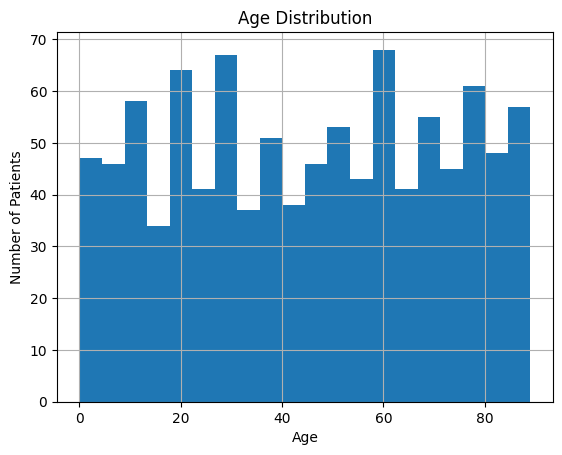

In [5]:
patients['age'].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Number of Patients')

##### Patients by Service

In [6]:
patients['service'].value_counts()

service
emergency           263
surgery             254
general_medicine    242
ICU                 241
Name: count, dtype: int64

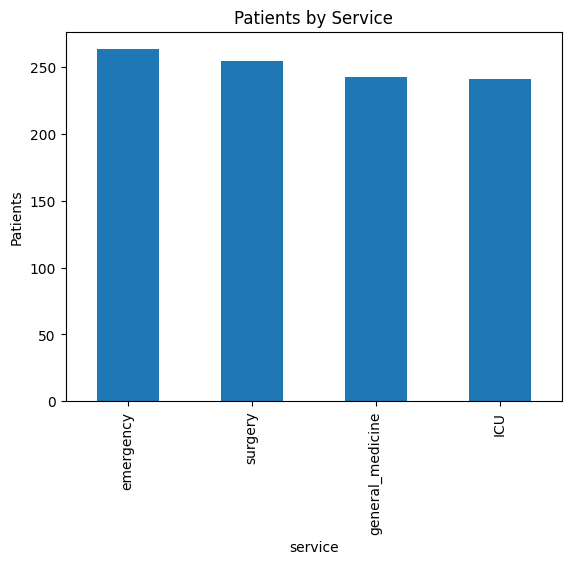

In [7]:
patients['service'].value_counts().plot(kind='bar')

plt.title('Patients by Service')
plt.ylabel('Patients')

plt.show()

##### Satisfaction Distribution

In [8]:
patients['satisfaction'].describe()

count    1000.000000
mean       79.597000
std        11.550325
min        60.000000
25%        70.000000
50%        80.000000
75%        89.250000
max        99.000000
Name: satisfaction, dtype: float64

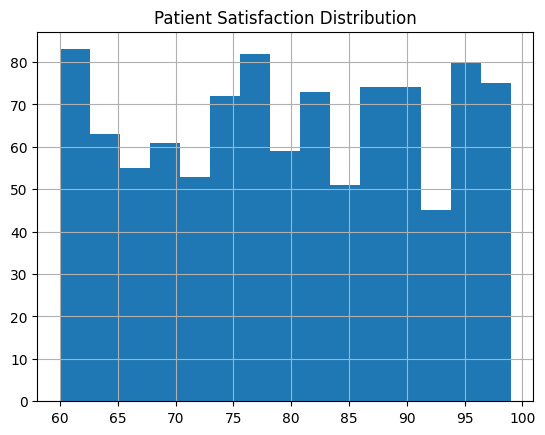

In [9]:
patients['satisfaction'].hist(bins=15)

plt.title('Patient Satisfaction Distribution')

plt.show()

##### Length of Stay Distribution

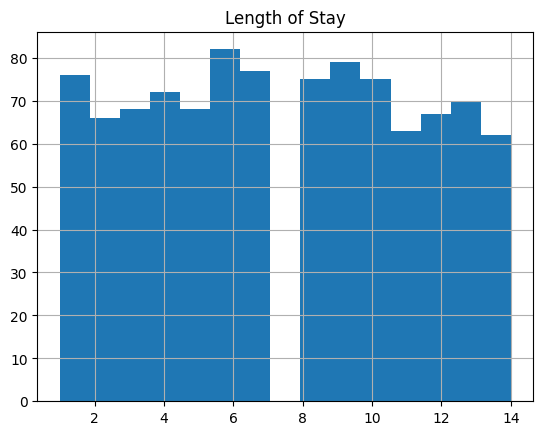

In [10]:
patients['length_of_stay'].describe()
patients['length_of_stay'].hist(bins=15)

plt.title('Length of Stay')
plt.show()

##### Average LOS by Service

In [11]:
patients.groupby('service')['length_of_stay'].mean().sort_values()

service
general_medicine    6.995868
emergency           7.159696
ICU                 7.605809
surgery             7.866142
Name: length_of_stay, dtype: float64

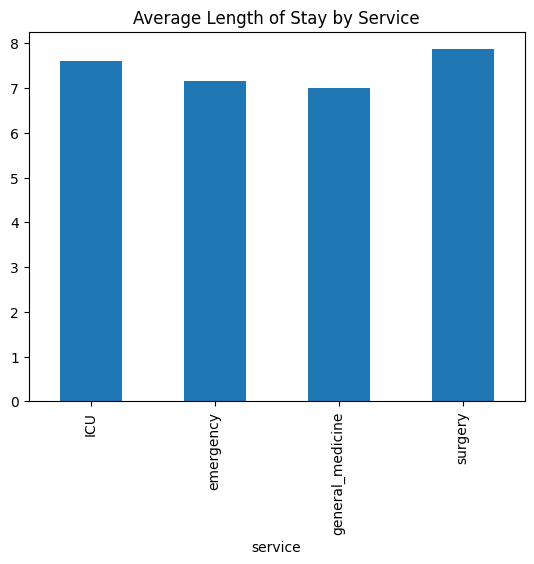

In [12]:
patients.groupby('service')['length_of_stay'].mean().plot(kind='bar')
plt.title('Average Length of Stay by Service')
plt.show()

##### Patient Satisfaction by Service

In [13]:
patients.groupby('service')['satisfaction'].mean()

service
ICU                 79.921162
emergency           79.547529
general_medicine    78.574380
surgery             80.314961
Name: satisfaction, dtype: float64

##### Admissions by Month

In [14]:
patients['admission_month'].value_counts().sort_index()

admission_month
April        81
August       88
December     74
February     80
January      85
July         82
June         81
March        75
May          85
November     83
October      92
September    94
Name: count, dtype: int64

#### Services Weekly Dataset

In [15]:
services.describe()

,week,month,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,bed_utilization_pct,admission_rate_pct,refusal_rate_pct,demand_pressure
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,26.500000,6.923077,30.346154,64.870192,28.129808,36.740385,80.000000,72.567308,92.470476,64.922675,35.077325,2.317392
std,15.044539,3.634755,15.172929,58.738572,14.676791,55.015763,11.125546,15.457759,14.523863,31.610225,31.610225,2.183066
min,1.000000,1.000000,8.000000,5.000000,5.000000,0.000000,60.000000,31.000000,27.777778,6.443299,0.000000,0.277778
25%,13.750000,4.000000,18.000000,23.750000,16.000000,0.000000,70.000000,60.000000,90.241935,31.951341,0.000000,0.902419
50%,26.500000,7.000000,27.500000,49.000000,26.000000,13.500000,81.000000,73.000000,100.000000,71.089932,28.910068,1.406673
75%,39.250000,10.000000,40.000000,86.000000,37.000000,52.500000,89.000000,86.000000,100.000000,100.000000,68.048659,3.129902
max,52.000000,12.000000,74.000000,388.000000,74.000000,363.000000,99.000000,99.000000,100.000000,100.000000,93.556701,15.520000


##### Available Beds


In [16]:
services['available_beds'].describe()

count    208.000000
mean      30.346154
std       15.172929
min        8.000000
25%       18.000000
50%       27.500000
75%       40.000000
max       74.000000
Name: available_beds, dtype: float64

##### Bed Utilization


In [17]:
services['bed_utilization_pct'].describe()

count    208.000000
mean      92.470476
std       14.523863
min       27.777778
25%       90.241935
50%      100.000000
75%      100.000000
max      100.000000
Name: bed_utilization_pct, dtype: float64

##### Utilization by Service

In [18]:
services.groupby('service')['bed_utilization_pct'].mean()

service
ICU                  84.381561
emergency           100.000000
general_medicine     97.313582
surgery              88.186759
Name: bed_utilization_pct, dtype: float64

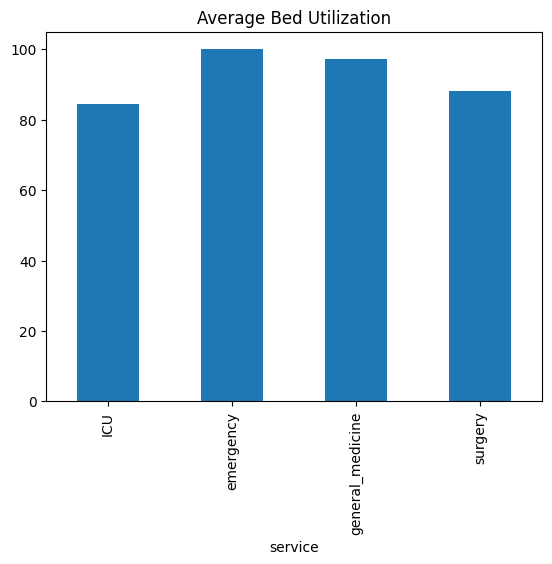

In [19]:
services.groupby('service')['bed_utilization_pct'].mean().plot(kind='bar')

plt.title("Average Bed Utilization")

plt.show()

##### Refusal Rate


In [20]:
services.groupby('service')['refusal_rate_pct'].mean()

service
ICU                 11.661473
emergency           76.768903
general_medicine    34.621146
surgery             17.257776
Name: refusal_rate_pct, dtype: float64

##### Admission Rate

In [21]:
services.groupby('service')['admission_rate_pct'].mean()

service
ICU                 88.338527
emergency           23.231097
general_medicine    65.378854
surgery             82.742224
Name: admission_rate_pct, dtype: float64

##### Demand Pressure

In [22]:
services.groupby('service')['demand_pressure'].mean()

service
ICU                 1.026420
emergency           5.216497
general_medicine    1.798304
surgery             1.228346
Name: demand_pressure, dtype: float64

##### Staff Morale

In [23]:
services.groupby('service')['staff_morale'].mean()

service
ICU                 70.980769
emergency           73.557692
general_medicine    73.096154
surgery             72.634615
Name: staff_morale, dtype: float64

##### Patient Satisfaction

In [24]:
services.groupby('service')['patient_satisfaction'].mean()

service
ICU                 81.615385
emergency           77.884615
general_medicine    81.230769
surgery             79.269231
Name: patient_satisfaction, dtype: float64

##### Event Counts

In [25]:
services['event'].value_counts()

event
none        164
flu          19
donation     14
strike       11
Name: count, dtype: int64

#### Staff Dataset

##### Roles

In [26]:
staff['role'].value_counts()

role
Nurse                69
Nursing_Assistant    23
Doctor               18
Name: count, dtype: int64

##### Staff Per Service

In [27]:
staff['service'].value_counts()

service
Icu                 32
Emergency           29
General_Medicine    27
Surgery             22
Name: count, dtype: int64

##### Nurses vs Doctors

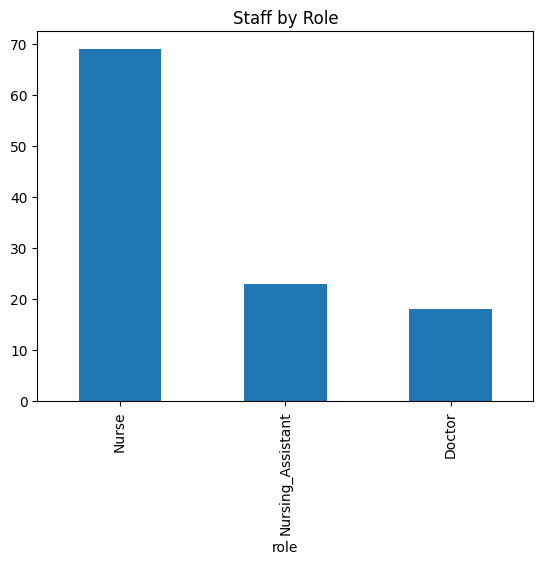

In [28]:
staff['role'].value_counts().plot(kind='bar')

plt.title('Staff by Role')

plt.show()

#### Staff Schedule

##### Attendance Rate

In [29]:
staff_schedule['present'].mean()*100

np.float64(59.98168498168498)

##### Weekly Attendance

In [31]:
staff_schedule.groupby('week')['present'].mean()*100

week
1     92.063492
2     91.269841
3      0.000000
4     84.920635
5     85.714286
6      0.000000
7     91.269841
8     86.507937
9      0.000000
10    88.888889
11    87.301587
12     0.000000
13    84.920635
14    82.539683
15     0.000000
16    89.682540
17    87.301587
18     0.000000
19    93.650794
20    91.269841
21     0.000000
22    91.269841
23    92.857143
24     0.000000
25    88.095238
26    94.444444
27     0.000000
28    92.063492
29    91.269841
30     0.000000
31    85.714286
32    88.095238
33     0.000000
34    88.888889
35    86.507937
36     0.000000
37    88.095238
38    92.063492
39     0.000000
40    87.301587
41    93.650794
42     0.000000
43    88.888889
44    88.888889
45     0.000000
46    86.507937
47    88.888889
48     0.000000
49    93.650794
50    88.888889
51     0.000000
52    85.714286
Name: present, dtype: float64

##### Attendance by service

In [ ]:
staff_schedule.groupby('service')['present'].mean() * 100

##### Attendance by Role

In [40]:
staff_schedule.groupby('role')['present'].mean() * 100

role
doctor               59.178322
nurse                60.115911
nursing_assistant    60.235732
Name: present, dtype: float64

#### Relationship Analysis

##### Does staff morale affect patient satisfaction?

In [42]:
services[['staff_morale','patient_satisfaction']].corr()

,staff_morale,patient_satisfaction
staff_morale,1.000000,0.008259
patient_satisfaction,0.008259,1.000000


##### Does demand pressure affect refusal rate?

In [43]:
services[['demand_pressure','refusal_rate_pct']].corr()

,demand_pressure,refusal_rate_pct
demand_pressure,1.000000,0.844273
refusal_rate_pct,0.844273,1.000000


##### Does available beds affect refusals?

In [44]:
services[['available_beds','patients_refused']].corr()

,available_beds,patients_refused
available_beds,1.000000,0.026614
patients_refused,0.026614,1.000000


##### Does bed utilization affect patient satisfaction?

In [45]:
services[['bed_utilization_pct','patient_satisfaction']].corr()

,bed_utilization_pct,patient_satisfaction
bed_utilization_pct,1.00000,-0.06156
patient_satisfaction,-0.06156,1.00000


##### Does bed utilization affect staff morale?

In [46]:
services[['bed_utilization_pct','staff_morale']].corr()

,bed_utilization_pct,staff_morale
bed_utilization_pct,1.000000,0.165671
staff_morale,0.165671,1.000000
